In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from nltk.corpus import stopwords
from nltk import *
from sklearn import *
import string
import json
import glob
import re
import csv
import bs4
import contractions
import os
from docx import Document
from pptx import Presentation
import requests
import PyPDF2
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from typing import List
import nltk
import import_ipynb
from Preprocessing import CleanText as cl 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


importing Jupyter notebook from Preprocessing.ipynb


In [2]:
def LoadTextData(filepath):
    ''' used this function due to all the cleaned text is written to a .txt file
        TFIFD vectorizer only need a list of strings not a text file
        using the file in read mode
    '''
    with open(filepath, 'r', encoding='utf-8') as file:
        data = file.readlines()  # Read lines into a list
    return data

# Load your data
data = LoadTextData(r"C:\\Projects\\Project SB\\TextModeling\\output\\CleanedText1.txt") # load your data as data variable

# Converts data into a list of strings
if not isinstance(data, list):
    data = [str(data)]  # Converts to list with a single string if data is a single string
else:
    data = [str(item).strip() for item in data]  # Ensure all items are strings

# TFIDFVectorizer identifies words based on the below conditions
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=100,
    stop_words="english",
    min_df=0.01
)
'''
   How TF-IDF Works
   Term Frequency (TF): This simply measures how frequently a term occurs in a particular document.
   TF(t,d) = (Number of times term t appears in document d) / (Total number of terms in document d)
   
   Inverse Document Frequency (IDF): This measures how important a term is across the entire document set.   
   IDF(t) = log(N / df(t))
           N is the total number of documents in the corpus
           df(t) is the number of documents containing term t
           TF-IDF: This is the product of TF and IDF.

   TF-IDF(t,d) = TF(t,d) * IDF(t)
   '''
vectors = vectorizer.fit_transform(data)
# transforms the document into set of words into matrix forms based on 

tfidf_dense = vectors.todense()

# Fit and transform the text data
vectors = vectorizer.fit_transform(data)

# Convert the matrix to a dense format and display
tfidf_dense = vectors.todense()

# Show feature names and their corresponding TF-IDF scores
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_dense, columns=feature_names)

# Display the resulting DataFrame
print(tfidf_df)


        add  agricultur  agriculture        al  approach      bean   benefit  \
0  0.038619    0.226199     0.049653  0.033102  0.077239  0.044136  0.121375   

   bioenergi    calcul        ce  ...   sustain     track       use      wast  \
0   0.038619  0.071721  0.182062  ...  0.171028  0.038619  0.259301  0.319988   

      waste     water     wheat      work        wu      year  
0  0.110341  0.044136  0.049653  0.038619  0.044136  0.033102  

[1 rows x 100 columns]


In [3]:
n_samples = vectors.shape[0]
inertia = []
K = range(1, min(11, n_samples + 1))
for k in K:
    model = KMeans(n_clusters=k, init="k-means++", max_iter=100, n_init=10, random_state=42)
    model.fit(vectors)
    inertia.append(model.inertia_)
true_k = min(5, n_samples)
model = KMeans(n_clusters=true_k, init="k-means++", max_iter=100, n_init=10, random_state=42)
model.fit(vectors)
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
with open("C:\\Projects\\Project SB\\TextModeling\\output\\outputcluster.txt", "w", encoding="utf-8") as f:
    for i in range(true_k):
        f.write(f"Cluster {i}\n")
        for ind in order_centroids[i, :10]:
            f.write(f' {terms[ind]}\n')
        f.write("\n\n")


In [4]:
KMeans_indices=model.fit_predict(vectors)

c:\Users\advai\anaconda3\envs\myenv\lib\site-packages\sklearn\decomposition\_pca.py:591: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


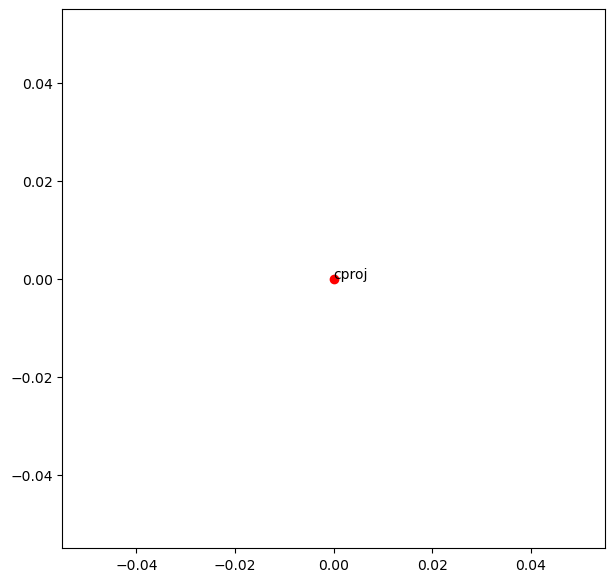

In [5]:
n_components = min(2, vectors.shape[1])
# Ensure n_components is not greater than the minimum number of samples or features
n_components = min(n_components, vectors.shape[0], vectors.shape[1])

pca = PCA(n_components=n_components)
scatter_plot_points = pca.fit_transform(vectors.toarray())

colors = ['r', 'b', 'c', 'y', 'm']
x_axis = [o[0] for o in scatter_plot_points]
y_axis = [o[1] for o in scatter_plot_points] if n_components > 1 else [0]*len(scatter_plot_points)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x_axis, y_axis, c=[colors[d] for d in KMeans_indices])

for i, txt in enumerate(data):
    ax.annotate(txt[0:5], (x_axis[i], y_axis[i]))

plt.savefig("C:\\Projects\\Project SB\\TextModeling\\outputcluster.png")
